In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns

In [53]:
# read data from travelling_salesman.csv
pd.set_option('display.max_columns', 1000)
data = pd.read_csv("room_air_quality.csv")
data.head() # display the first few rows of the dataset

,Timestamp,Temperature (?C),Humidity (%),CO2 (ppm),PM2.5 (?g/m?),PM10 (?g/m?),TVOC (ppb),CO (ppm),Light Intensity (lux),Motion Detected,Occupancy Count,Ventilation Status
0,18-02-2024 08:00,21.75,63.11,989.74,31.17,89.66,226.83,2.84,646.86,0.0,49.0,Open
1,18-02-2024 08:05,27.51,68.03,924.59,27.32,44.82,116.76,3.12,845.45,1.0,11.0,Open
2,18-02-2024 08:10,25.32,53.51,604.05,73.84,71.08,56.59,3.59,560.03,1.0,29.0,Closed
3,18-02-2024 08:15,23.99,58.52,692.20,62.94,10.90,228.06,2.66,499.84,1.0,28.0,Closed
4,18-02-2024 08:20,19.56,69.34,533.12,26.56,88.06,267.26,1.76,411.36,1.0,16.0,Closed


In [54]:
data = data.drop(columns=["CO2 (ppm)", "PM2.5 (?g/m?)", "PM10 (?g/m?)", "TVOC (ppb)", "CO (ppm)", "Motion Detected", "Occupancy Count", "Ventilation Status"])

In [55]:
data.head()

,Timestamp,Temperature (?C),Humidity (%),Light Intensity (lux)
0,18-02-2024 08:00,21.75,63.11,646.86
1,18-02-2024 08:05,27.51,68.03,845.45
2,18-02-2024 08:10,25.32,53.51,560.03
3,18-02-2024 08:15,23.99,58.52,499.84
4,18-02-2024 08:20,19.56,69.34,411.36


In [69]:
# Convert 'date' column to datetime format
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
# Verify data type
print(data['Timestamp'].dtype)  # Output: datetime64[ns]

datetime64[us]


C:\Users\kelsng\AppData\Local\Temp\ipykernel_26656\3919437034.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Timestamp'] = pd.to_datetime(data['Timestamp'])


In [70]:
#Extract year, month and day
data["year"] = data["Timestamp"].dt.year
data["month"] = data["Timestamp"].dt.month
data["day"] = data["Timestamp"].dt.day

In [71]:
# Extract day of the week (0 = Monday, 6 = Sunday)
data['day_of_week'] = data['Timestamp'].dt.dayofweek
# Extract hour, minute, and second
data['hour'] = data['Timestamp'].dt.hour
data['minute'] = data['Timestamp'].dt.minute
data['second'] = data['Timestamp'].dt.second
print(data.head())

            Timestamp  Temperature (?C)  Humidity (%)  Light Intensity (lux)  \
0 2024-02-18 08:00:00             21.75         63.11                 646.86   
1 2024-02-18 08:05:00             27.51         68.03                 845.45   
2 2024-02-18 08:10:00             25.32         53.51                 560.03   
3 2024-02-18 08:15:00             23.99         58.52                 499.84   
4 2024-02-18 08:20:00             19.56         69.34                 411.36   

   year  month  day  day_of_week  hour  minute  second  
0  2024      2   18            6     8       0       0  
1  2024      2   18            6     8       5       0  
2  2024      2   18            6     8      10       0  
3  2024      2   18            6     8      15       0  
4  2024      2   18            6     8      20       0  


In [72]:
data['quarter'] = data['Timestamp'].dt.quarter
data['week_of_year'] = data['Timestamp'].dt.isocalendar().week
data['is_weekend'] = data['day_of_week'].isin([5, 6])

In [73]:
data.head()

,Timestamp,Temperature (?C),Humidity (%),Light Intensity (lux),year,month,day,day_of_week,hour,minute,second,quarter,week_of_year,is_weekend
0,2024-02-18 08:00:00,21.75,63.11,646.86,2024,2,18,6,8,0,0,1,7,True
1,2024-02-18 08:05:00,27.51,68.03,845.45,2024,2,18,6,8,5,0,1,7,True
2,2024-02-18 08:10:00,25.32,53.51,560.03,2024,2,18,6,8,10,0,1,7,True
3,2024-02-18 08:15:00,23.99,58.52,499.84,2024,2,18,6,8,15,0,1,7,True
4,2024-02-18 08:20:00,19.56,69.34,411.36,2024,2,18,6,8,20,0,1,7,True


In [74]:
# checking Missing data

data.isnull().sum()

Timestamp                0
Temperature (?C)         0
Humidity (%)             0
Light Intensity (lux)    0
year                     0
month                    0
day                      0
day_of_week              0
hour                     0
minute                   0
second                   0
quarter                  0
week_of_year             0
is_weekend               0
dtype: int64

In [75]:
data.isnull().mean() * 100

Timestamp                0.0
Temperature (?C)         0.0
Humidity (%)             0.0
Light Intensity (lux)    0.0
year                     0.0
month                    0.0
day                      0.0
day_of_week              0.0
hour                     0.0
minute                   0.0
second                   0.0
quarter                  0.0
week_of_year             0.0
is_weekend               0.0
dtype: float64

In [76]:
data.duplicated().sum()

np.int64(0)

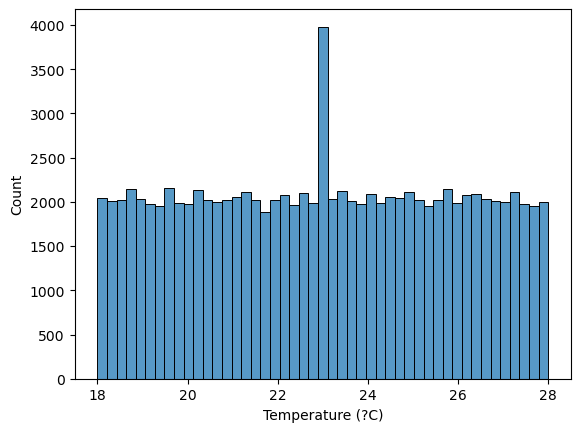

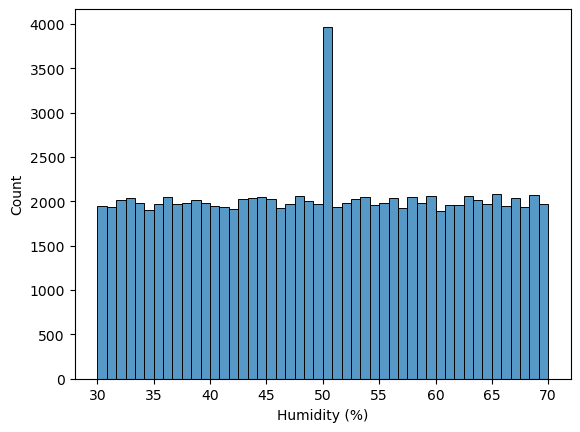

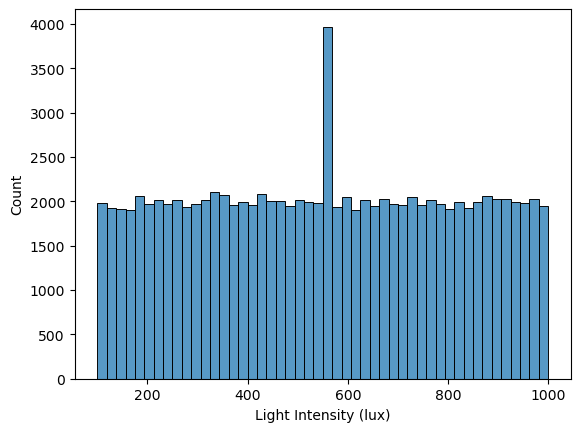

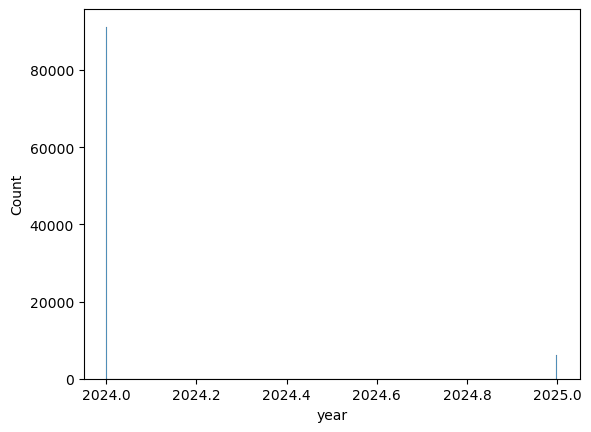

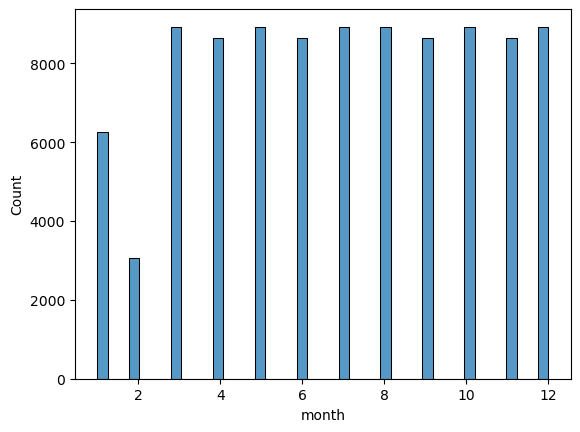

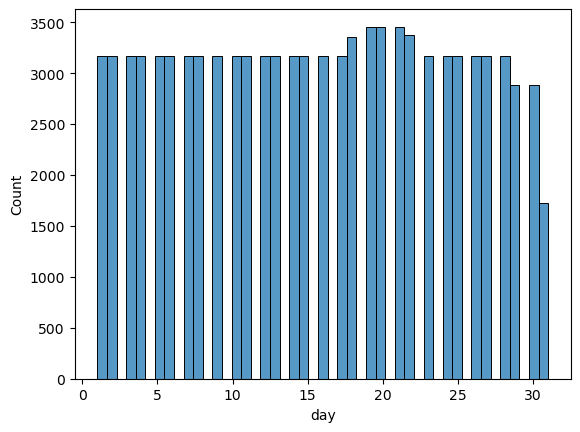

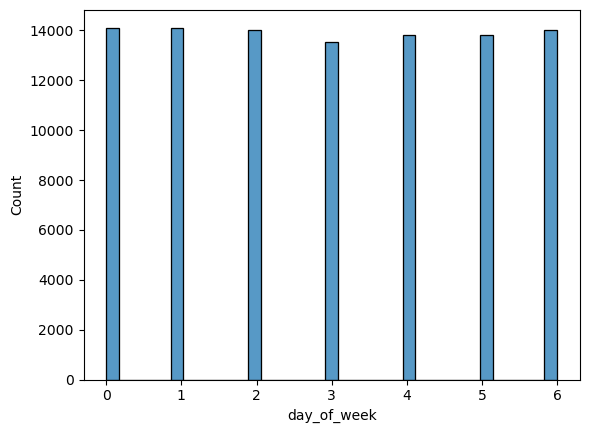

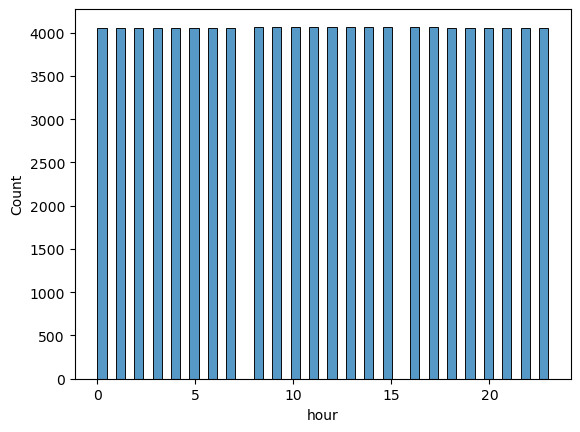

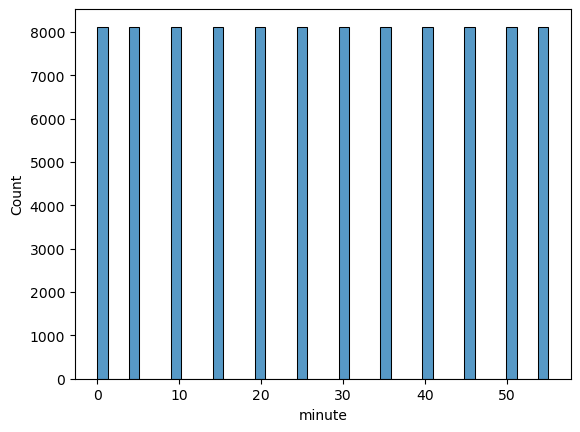

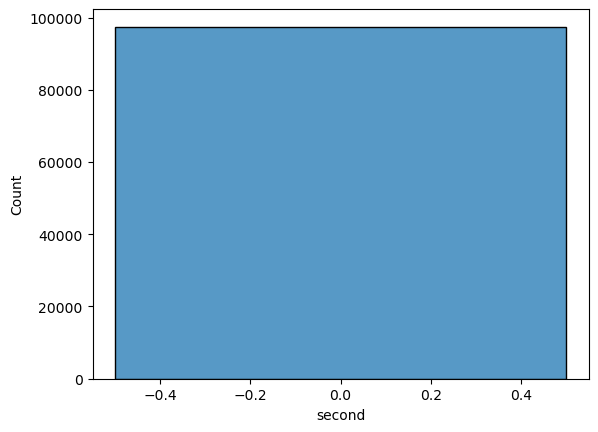

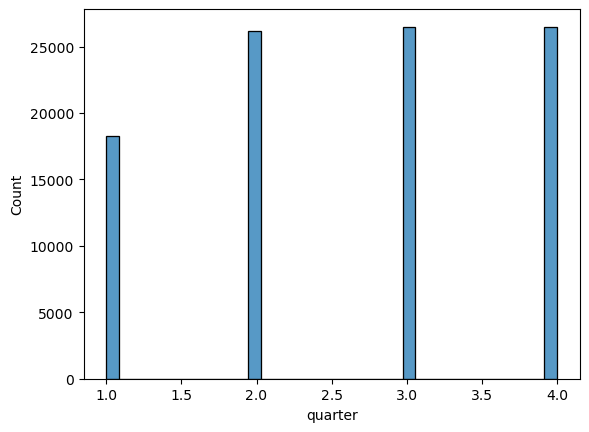

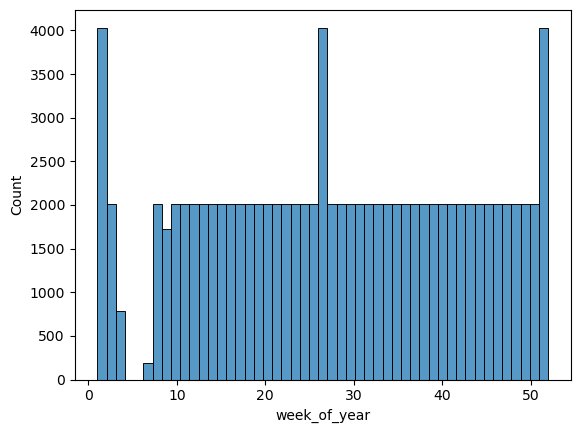

In [77]:
#histogram to understand the distribution
for i in data.select_dtypes(include="number").columns:
    sns.histplot(data=data, x=i)
    plt.show()


In [61]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

In [62]:
mean_Temperature = data["Temperature (?C)"].mean()
data["Temperature (?C)"] = data["Temperature (?C)"].fillna(mean_Temperature)
mean_Humidity = data["Humidity (%)"].mean()
data["Humidity (%)"] = data["Humidity (%)"].fillna(mean_Humidity)
mean_LightIntensityLux = data["Light Intensity (lux)"].mean()
data["Light Intensity (lux)"] = data["Light Intensity (lux)"].fillna(mean_LightIntensityLux)


In [78]:
data.head()

,Timestamp,Temperature (?C),Humidity (%),Light Intensity (lux),year,month,day,day_of_week,hour,minute,second,quarter,week_of_year,is_weekend
0,2024-02-18 08:00:00,21.75,63.11,646.86,2024,2,18,6,8,0,0,1,7,True
1,2024-02-18 08:05:00,27.51,68.03,845.45,2024,2,18,6,8,5,0,1,7,True
2,2024-02-18 08:10:00,25.32,53.51,560.03,2024,2,18,6,8,10,0,1,7,True
3,2024-02-18 08:15:00,23.99,58.52,499.84,2024,2,18,6,8,15,0,1,7,True
4,2024-02-18 08:20:00,19.56,69.34,411.36,2024,2,18,6,8,20,0,1,7,True


In [64]:
data.isnull().mean() * 100

Timestamp                0.0
Temperature (?C)         0.0
Humidity (%)             0.0
Light Intensity (lux)    0.0
dtype: float64

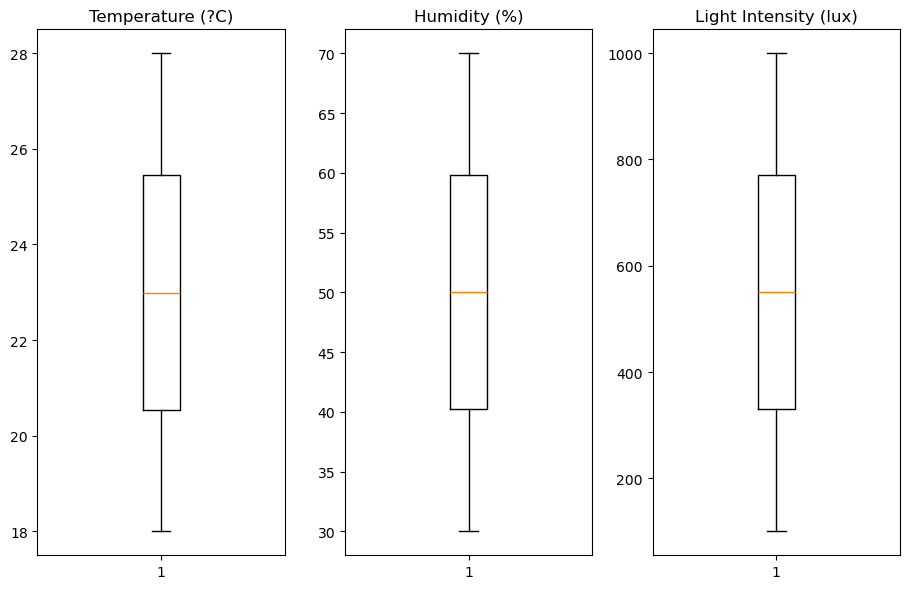

In [65]:
#Outliers
#box plot of timestamp, Te
plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 2)
plt.boxplot(data["Temperature (?C)"])
plt.title("Temperature (?C)")

plt.subplot(1, 4, 3)
plt.boxplot(data["Humidity (%)"])
plt.title("Humidity (%)")

plt.subplot(1, 4, 4)
plt.boxplot(data["Light Intensity (lux)"])
plt.title("Light Intensity (lux)")

plt.tight_layout()
plt.show()

In [79]:
data = data.drop(columns=["Timestamp"])

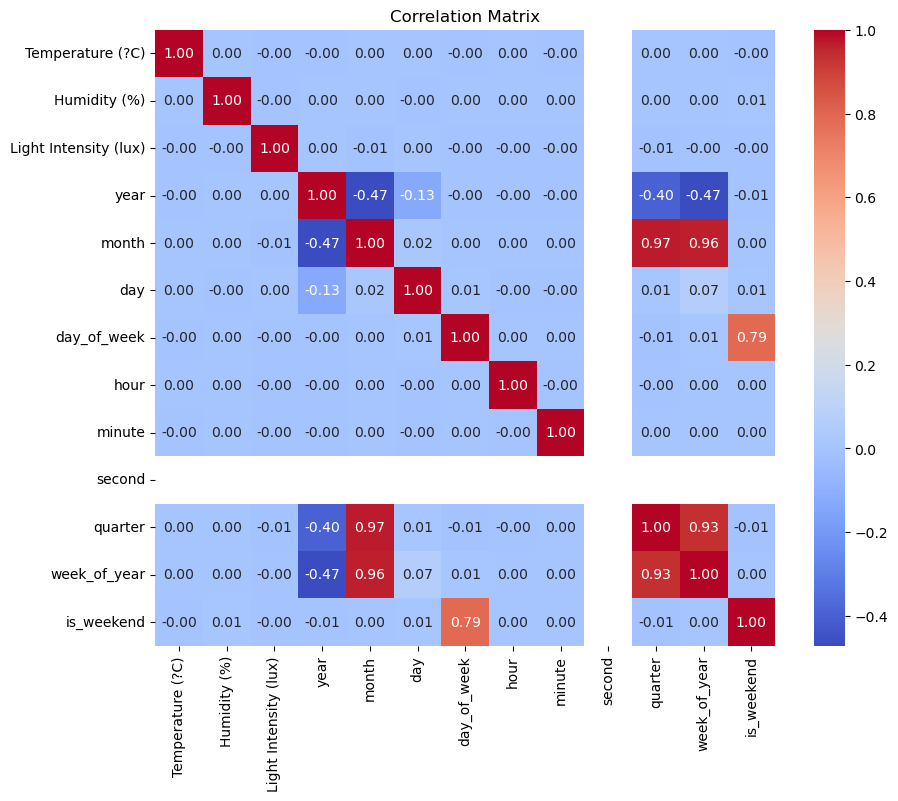

In [80]:
# correlation matrix with seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
data.head()

,Temperature (?C),Humidity (%),Light Intensity (lux),year,month,day,day_of_week,hour,minute,second,quarter,week_of_year,is_weekend
0,21.75,63.11,646.86,2024,2,18,6,8,0,0,1,7,True
1,27.51,68.03,845.45,2024,2,18,6,8,5,0,1,7,True
2,25.32,53.51,560.03,2024,2,18,6,8,10,0,1,7,True
3,23.99,58.52,499.84,2024,2,18,6,8,15,0,1,7,True
4,19.56,69.34,411.36,2024,2,18,6,8,20,0,1,7,True
